# EDA

0 → Malignant (cancerous)

1 → Benign (non-cancerous)

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add target column (0 = malignant, 1 = benign)

# Show first 5 rows
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.shape

(569, 31)

In [4]:
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.627417
0,0.372583


In [5]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [6]:
x = df.drop('target',axis=1)
y = df['target']

In [7]:
y.tail()

,target
564,0
565,0
566,0
567,0
568,1


In [8]:
x.iloc[:4,1:4]

,mean texture,mean perimeter,mean area
0,10.38,122.80,1001.0
1,17.77,132.90,1326.0
2,21.25,130.00,1203.0
3,20.38,77.58,386.1


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=0)

stratify=y?

✅ Prevents class imbalance in train/test split

✅ Ensures same proportion of target labels in both sets

✅ Improves model generalization

In [11]:
x_train.shape

(398, 30)

In [12]:
y_test.shape

(171,)

In [13]:
y_train.shape

(398,)

In [14]:
x_test.shape

(171, 30)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
classifier = LogisticRegression(random_state=0)

#Forward selection(SFS) from mlextend

In [17]:
# it is avalible in mlxtend

In [18]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [19]:
sfs = SFS(classifier,
          k_features = 30,
          forward= True,
          floating =False,
          scoring = 'accuracy',
          cv = 0
          )

In [20]:
sfs.fit(x,y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

SequentialFeatureSelector(cv=0, estimator=LogisticRegression(random_state=0),
                          k_features=(30, 30), scoring='accuracy')

In [21]:
df_sfs_results = pd.DataFrame(sfs.subsets_).transpose()

In [22]:
df_sfs_results['avg_score'].idxmax()

np.int64(18)

In [23]:
df_sfs_results

,feature_idx,cv_scores,avg_score,feature_names
1,"(22,)",[0.9191564147627417],0.919156,"(worst perimeter,)"
2,"(21, 22)",[0.9507908611599297],0.950791,"(worst texture, worst perimeter)"
3,"(0, 21, 22)",[0.9560632688927944],0.956063,"(mean radius, worst texture, worst perimeter)"
4,"(0, 21, 22, 25)",[0.9595782073813708],0.959578,"(mean radius, worst texture, worst perimeter, ..."
5,"(0, 20, 21, 22, 25)",[0.961335676625659],0.961336,"(mean radius, worst radius, worst texture, wor..."
6,"(0, 2, 20, 21, 22, 25)",[0.9630931458699473],0.963093,"(mean radius, mean perimeter, worst radius, wo..."
7,"(0, 2, 20, 21, 22, 25, 26)",[0.9630931458699473],0.963093,"(mean radius, mean perimeter, worst radius, wo..."
8,"(0, 2, 15, 20, 21, 22, 25, 26)",[0.9648506151142355],0.964851,"(mean radius, mean perimeter, compactness erro..."
9,"(0, 2, 7, 15, 20, 21, 22, 25, 26)",[0.9630931458699473],0.963093,"(mean radius, mean perimeter, mean concave poi..."
10,"(0, 2, 7, 15, 19, 20, 21, 22, 25, 26)",[0.9648506151142355],0.964851,"(mean radius, mean perimeter, mean concave poi..."


# Backward selection selection(SFS) from mlextend

FORWARD = FALSE


In [24]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS

In [25]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [26]:
sfs = SFS(classifier,
          k_features = 2,
          forward = False,
          floating=False,
          scoring ='accuracy',

          cv = 0
          )

In [27]:
sfs.fit(x,y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

SequentialFeatureSelector(cv=0, estimator=LogisticRegression(random_state=0),
                          forward=False, k_features=(2, 2), scoring='accuracy')

In [28]:
df_sfs_results_backward_elemi = pd.DataFrame(sfs.subsets_).transpose()

In [29]:
df_sfs_results_backward_elemi

,feature_idx,cv_scores,avg_score,feature_names
30,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9472759226713533],0.947276,"(mean radius, mean texture, mean perimeter, me..."
29,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9578207381370826],0.957821,"(mean radius, mean texture, mean perimeter, me..."
28,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9648506151142355],0.964851,"(mean radius, mean texture, mean perimeter, me..."
27,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9648506151142355],0.964851,"(mean radius, mean texture, mean perimeter, me..."
26,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9666080843585237],0.966608,"(mean radius, mean texture, mean perimeter, me..."
25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9666080843585237],0.966608,"(mean radius, mean texture, mean perimeter, me..."
24,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9666080843585237],0.966608,"(mean radius, mean texture, mean perimeter, me..."
23,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9666080843585237],0.966608,"(mean radius, mean texture, mean perimeter, me..."
22,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9666080843585237],0.966608,"(mean radius, mean texture, mean perimeter, me..."
21,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0.9666080843585237],0.966608,"(mean radius, mean texture, mean perimeter, me..."


In [30]:
df_sfs_results_backward_elemi['avg_score'].idxmax()

np.int64(26)

**For Regression Problem scoring can be 'neg_mean_squared_error' and instead of passing classifier, Regresser can be passed here**

# Backward elimination RFE() from Sklearn



RFE(estimator, n_features_to_select) is a class which stands for Reursive Feature Elimination is derived from the commonly used sklearn library for machine learning algorithms, it accepts the following major parameters :


**estimator** (pass with model in the sample code above) acts as an object for the the feature selection process. For regression problems shown, coef_ attribute is used to determine feature importance. For tree-like algorithm, feature_importances_ attribute is used instead.

**n_features_to_select** refers to the number of features to select. **If None, half of the features are selected.**

For other possible parameters, please refer to the documentation.

In [31]:
from sklearn.feature_selection import RFE

RFE (Recursive Feature Elimination) is available in Scikit-Learn under sklearn.feature_selection.


How to Use RFE in Scikit-Learn?

RFE helps select the most important features by recursively removing the least important ones.

In [32]:
rfe = RFE(classifier,n_features_to_select=5)

In [33]:
rfe = rfe.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [34]:
rfe.support_

array([False, False, False, False, False, False,  True, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True, False, False])

In [35]:
rfe.ranking_

array([ 2, 12, 18, 24, 15,  7,  1,  6,  8, 23,  1,  3, 16, 13, 25, 11, 10,
       21, 22, 26, 19,  9,  4, 20,  5,  1,  1,  1, 17, 14])

In [36]:
rfe.classes_
rfe.estimator_

LogisticRegression(random_state=0)

In [37]:
rfe.feature_names_in_

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype=object)

BEST COLUMNS AS PER **RFE**

In [38]:
x_train.columns[rfe.support_].tolist()

['mean concavity',
 'radius error',
 'worst compactness',
 'worst concavity',
 'worst concave points']

# What should be the ideal number of features?

In [39]:
pip install mlxtend


In [40]:
import mlxtend
print(mlxtend.__version__)

0.23.4


In [41]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [42]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [43]:
sfs = SFS(
    classifier,
    k_features=30,
    forward=True,
    floating=False,
    scoring ='accuracy',
    cv=5
#Use SFS to select the top 5 features
)

In [44]:
sfs.fit(x,y)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/li

SequentialFeatureSelector(estimator=LogisticRegression(random_state=0),
                          k_features=(30, 30), scoring='accuracy')

In [45]:
sfs.estimator

LogisticRegression(random_state=0)

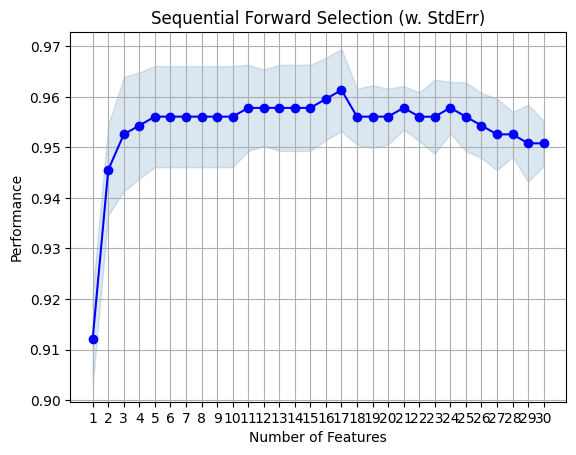

In [46]:
fig = plot_sfs(sfs.get_metric_dict(), kind='std_err')
plt.title('Sequential Forward Selection (w. StdErr)')
plt.grid()
plt.show()

# UNIVARIATE SELECTION

In [62]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [63]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [64]:
x.shape

(569, 30)

In [65]:
y.shape

(569,)

In [66]:
BestFeatures = SelectKBest(score_func=chi2,k=5)

In [67]:
fit = BestFeatures.fit(x,y)
fit.scores_

array([2.66104917e+02, 9.38975081e+01, 2.01110286e+03, 5.39916559e+04,
       1.49899264e-01, 5.40307549e+00, 1.97123536e+01, 1.05440354e+01,
       2.57379775e-01, 7.43065536e-05, 3.46752472e+01, 9.79353970e-03,
       2.50571896e+02, 8.75850471e+03, 3.26620664e-03, 6.13785332e-01,
       1.04471761e+00, 3.05231563e-01, 8.03633831e-05, 6.37136566e-03,
       4.91689157e+02, 1.74449400e+02, 3.66503542e+03, 1.12598432e+05,
       3.97365694e-01, 1.93149220e+01, 3.95169151e+01, 1.34854195e+01,
       1.29886140e+00, 2.31522407e-01])

In [68]:
dfscores = pd.DataFrame(fit.scores_)
dfscores

,0
0,266.104917
1,93.897508
2,2011.102864
3,53991.655924
4,0.149899
5,5.403075
6,19.712354
7,10.544035
8,0.257380
9,0.000074


In [69]:
dfcolumns = pd.DataFrame(x.columns)
dfcolumns

,0
0,mean radius
1,mean texture
2,mean perimeter
3,mean area
4,mean smoothness
5,mean compactness
6,mean concavity
7,mean concave points
8,mean symmetry
9,mean fractal dimension


In [70]:
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']
print(featureScores.nlargest(10,'Score'))

              Specs          Score
23       worst area  112598.431564
3         mean area   53991.655924
13       area error    8758.504705
22  worst perimeter    3665.035416
2    mean perimeter    2011.102864
20     worst radius     491.689157
0       mean radius     266.104917
12  perimeter error     250.571896
21    worst texture     174.449400
1      mean texture      93.897508


 ##UNIVARIATE _ 2


In [71]:
df = pd.read_csv('train.csv')

In [72]:
df.shape

(2000, 21)

In [73]:
y = df.iloc[:,-1]

In [74]:
x = df.iloc[:,0:20]

In [75]:
x.shape

(2000, 20)

In [76]:
bestfeatures = SelectKBest(score_func=chi2,k=15)
fit = bestfeatures.fit(x,y)

In [77]:
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)

In [78]:
#concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(15,'Score'))

            Specs          Score
13            ram  931267.519053
11      px_height   17363.569536
0   battery_power   14129.866576
12       px_width    9810.586750
8       mobile_wt      95.972863
6      int_memory      89.839124
15           sc_w      16.480319
16      talk_time      13.236400
4              fc      10.135166
14           sc_h       9.614878
10             pc       9.186054
9         n_cores       9.097556
18   touch_screen       1.928429
5          four_g       1.521572
7           m_dep       0.745820


# FEATURE_IMPORTANCE

In [81]:
from sklearn.ensemble import ExtraTreesClassifier

In [82]:
modle = ExtraTreesClassifier()
modle.fit(x,y)

ExtraTreesClassifier()

In [83]:
print(pd.DataFrame(modle.feature_names_in_))

                0
0   battery_power
1            blue
2     clock_speed
3        dual_sim
4              fc
5          four_g
6      int_memory
7           m_dep
8       mobile_wt
9         n_cores
10             pc
11      px_height
12       px_width
13            ram
14           sc_h
15           sc_w
16      talk_time
17        three_g
18   touch_screen
19           wifi


In [84]:
modle.feature_importances_

array([0.06364485, 0.01865526, 0.03131131, 0.01862274, 0.03144262,
       0.01711354, 0.03427356, 0.03228858, 0.03375461, 0.03185728,
       0.03258999, 0.04563262, 0.04826845, 0.41220759, 0.03184579,
       0.03218692, 0.03309838, 0.01420651, 0.01809871, 0.01890071])

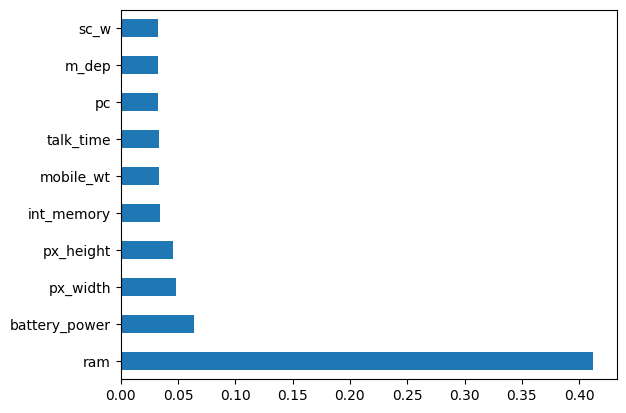

In [85]:
#plot graph of feature importances for better visualization
feat_importances = pd.Series(modle.feature_importances_, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

# Correlation Matrix with Heatmap

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

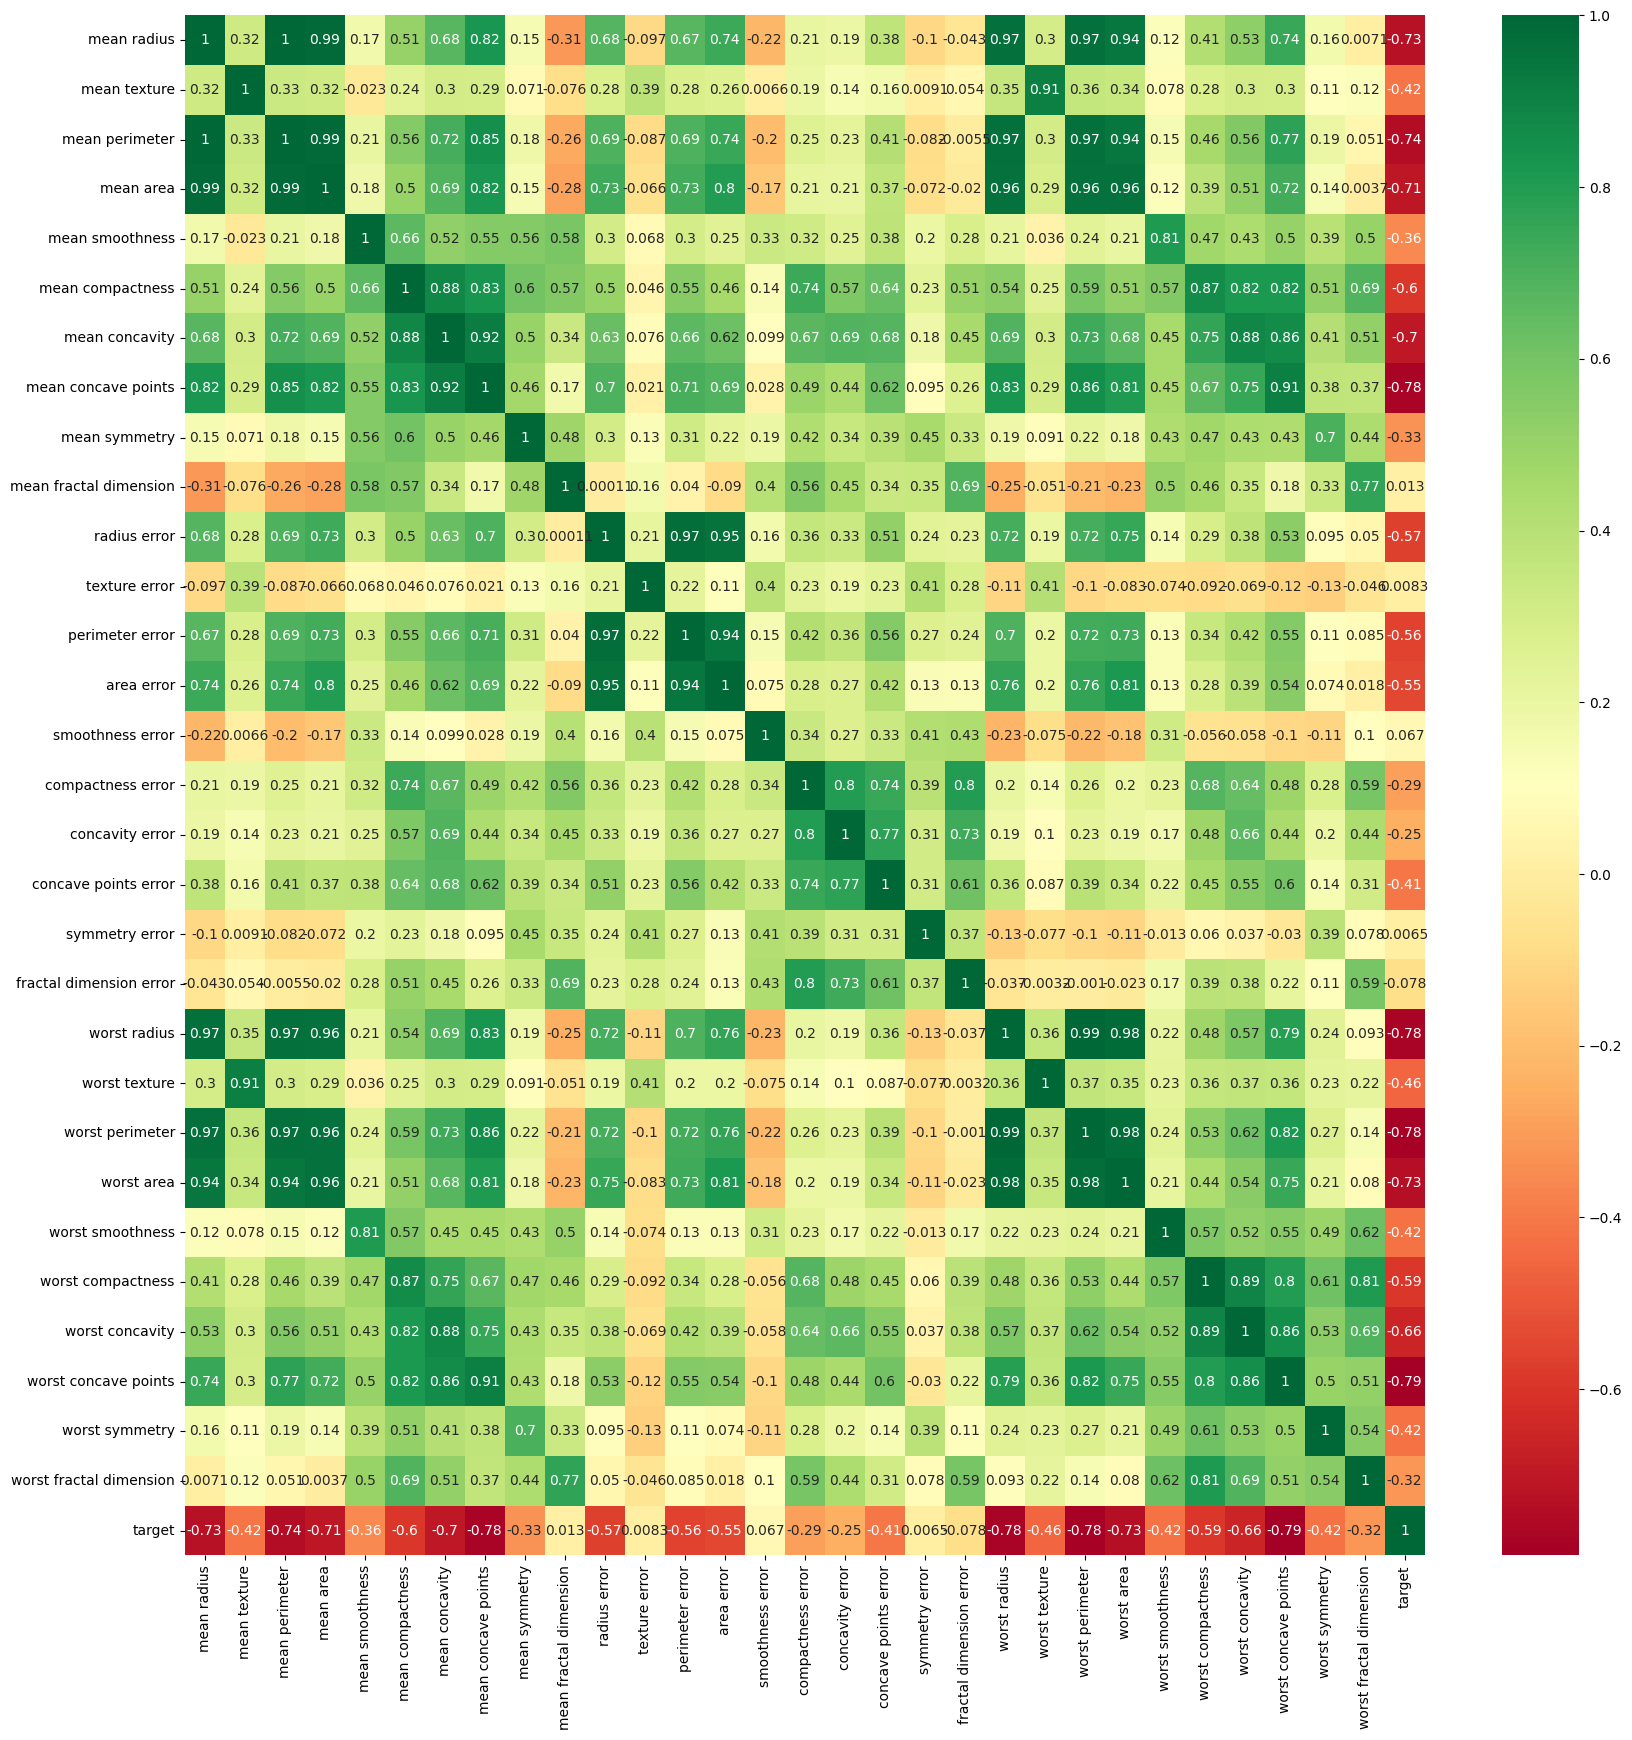

In [57]:
#get correlations of each features in dataset
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
plt.legend
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="RdYlGn")

# Mutual_info_classif


In [59]:
from sklearn.feature_selection import mutual_info_classif

importances = mutual_info_classif(x, y)
selected_features = x.columns[importances > 0.01]  # Select features with high importance

print("Selected Features:", selected_features.tolist())

Selected Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'radius error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


ONE PEMDING ON FEATURE SLEECTIO  NOTES TRY IT